In [6]:
import os
import cv2

# Paths
image_dir = "train/images"
label_dir = "train/labels"
output_dir = "dataset_cls"

classes = ['fiber', 'fragment', 'film', 'pellet']

os.makedirs(output_dir, exist_ok=True)
for cls in classes:
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)

for img_file in os.listdir(image_dir):
    img_path = os.path.join(image_dir, img_file)
    label_path = os.path.join(label_dir, img_file.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    if not os.path.exists(label_path):
        continue

    with open(label_path, 'r') as f:
        for i, line in enumerate(f.readlines()):
            cls_id, x, y, bw, bh = map(float, line.split())

            # Convert YOLO → pixel coords
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            crop = img[y1:y2, x1:x2]

            class_name = classes[int(cls_id)]
            save_path = os.path.join(output_dir, class_name, f"{img_file}_{i}.jpg")

            if crop.size > 0:
                cv2.imwrite(save_path, crop)

In [7]:
from torchvision import datasets

dataset = datasets.ImageFolder("dataset_cls", transform=transform)

In [8]:
from torch.utils.data import DataLoader, random_split

# Split dataset (80 train / 20 val)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [9]:
import torch
import torch.nn as nn
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model('efficientnet_b0', pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 4)
model = model.to(device)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

In [13]:
len(dataset)

3859

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
import timm

# ======================
# CONFIG
# ======================
BATCH_SIZE = 16
EPOCHS = 3
SUBSET_SIZE = 1000  # reduce dataset for speed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================
# REDUCE DATASET SIZE
# ======================
if len(dataset) > SUBSET_SIZE:
    dataset = Subset(dataset, list(range(SUBSET_SIZE)))

# ======================
# TRAIN / VAL SPLIT
# ======================
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# ======================
# DATALOADERS (IMPORTANT FIX)
# ======================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ======================
# MODEL (EfficientNet)
# ======================
model = timm.create_model('efficientnet_b0', pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 4)
model = model.to(device)

# ======================
# FREEZE BACKBONE (FASTER)
# ======================
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

# ======================
# LOSS + OPTIMIZER
# ======================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

# ======================
# TRAINING LOOP
# ======================
for epoch in range(EPOCHS):
    print(f"\n🚀 Starting Epoch {epoch+1}/{EPOCHS}")

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        # 🔥 Progress print every 50 batches
        if i % 50 == 0:
            print(f"Batch {i}/{len(train_loader)} running...")

    train_acc = 100 * correct / total

    # ======================
    # VALIDATION
    # ======================
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    print(f"\nEpoch {epoch+1} Results:")
    print(f"Train Loss: {running_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print("=" * 50)

# ======================
# SAVE MODEL
# ======================
torch.save(model.state_dict(), "microplastic_model.pth")

print("\n✅ Training complete and model saved!")


🚀 Starting Epoch 1/3
Batch 0/50 running...

Epoch 1 Results:
Train Loss: 10.5354
Train Accuracy: 96.12%
Validation Accuracy: 99.50%

🚀 Starting Epoch 2/3
Batch 0/50 running...

Epoch 2 Results:
Train Loss: 1.0156
Train Accuracy: 100.00%
Validation Accuracy: 100.00%

🚀 Starting Epoch 3/3
Batch 0/50 running...

Epoch 3 Results:
Train Loss: 1.1532
Train Accuracy: 99.50%
Validation Accuracy: 100.00%

✅ Training complete and model saved!


In [15]:
# ======================
# 🔥 FIXED PIPELINE (NO FAKE ACCURACY)
# ======================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================
# 1. STRONGER TRANSFORMS (REALISTIC DATA)
# ======================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# ======================
# 2. LOAD DATASET
# ======================

full_dataset = datasets.ImageFolder("dataset_cls", transform=train_transform)

# Reduce dataset for speed
SUBSET_SIZE = 1200
if len(full_dataset) > SUBSET_SIZE:
    full_dataset = Subset(full_dataset, list(range(SUBSET_SIZE)))

# ======================
# 3. PROPER SPLIT
# ======================

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# ⚠️ Apply correct transform to validation set
val_dataset.dataset.transform = val_transform

# ======================
# 4. DATALOADERS
# ======================

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

# ======================
# 5. MODEL (UNFREEZE PARTIAL)
# ======================

model = timm.create_model('efficientnet_b0', pretrained=True)

# Unfreeze ALL layers (less overfitting)
for param in model.parameters():
    param.requires_grad = True

# Replace classifier
model.classifier = nn.Linear(model.classifier.in_features, 4)
model = model.to(device)

# ======================
# 6. LOSS + OPTIMIZER (LOW LR)
# ======================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

# ======================
# 7. TRAINING LOOP
# ======================

EPOCHS = 3

for epoch in range(EPOCHS):
    print(f"\n🚀 Starting Epoch {epoch+1}/{EPOCHS}")

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        if i % 50 == 0:
            print(f"Batch {i}/{len(train_loader)} running...")

    train_acc = 100 * correct / total

    # ======================
    # VALIDATION
    # ======================
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    print(f"\nEpoch {epoch+1} Results:")
    print(f"Train Loss: {running_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print("=" * 50)

# ======================
# SAVE MODEL
# ======================

torch.save(model.state_dict(), "microplastic_model.pth")

print("\n✅ Training complete and model saved!")


🚀 Starting Epoch 1/3
Batch 0/60 running...
Batch 50/60 running...

Epoch 1 Results:
Train Loss: 8.7727
Train Accuracy: 98.44%
Validation Accuracy: 100.00%

🚀 Starting Epoch 2/3
Batch 0/60 running...
Batch 50/60 running...

Epoch 2 Results:
Train Loss: 1.4418
Train Accuracy: 99.48%
Validation Accuracy: 100.00%

🚀 Starting Epoch 3/3
Batch 0/60 running...
Batch 50/60 running...

Epoch 3 Results:
Train Loss: 0.6106
Train Accuracy: 99.79%
Validation Accuracy: 100.00%

✅ Training complete and model saved!


In [34]:
from ultralytics import YOLO

# Load model
model = YOLO("yolov8n.pt")  # nano = fast

# Train
model.train(
    data="data.yaml",
    epochs=10,
    imgsz=640,
    batch=8
)

100%|██████████| 6.23M/6.23M [00:03<00:00, 2.11MB/s]


Ultralytics YOLOv8.1.0 🚀 Python-3.10.9 torch-2.2.1+cpu CPU (13th Gen Intel Core(TM) i7-1355U)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=data.yaml, epochs=10, time=None, patience=50, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, 

100%|██████████| 755k/755k [00:00<00:00, 2.96MB/s]



Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytic

train: Scanning C:\Users\HP\OneDrive\Desktop\synapse\train\labels... 320 images, 0 backgrounds, 0 corrupt: 100%|██████████| 320/320 [00:00<00:00, 1141.73it/s]


...

                   all         80        890      0.983      0.981      0.976      0.645



10 epochs completed in 0.431 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 6.2MB
Optimizer stripped from runs\detect\train\weights\best.pt, 6.2MB

Validating runs\detect\train\weights\best.pt...
Ultralytics YOLOv8.1.0 🚀 Python-3.10.9 torch-2.2.1+cpu CPU (13th Gen Intel Core(TM) i7-1355U)
Model summary (fused): 168 layers, 3006428 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:08<00:00,  1.64s/it]


                   all         80        890      0.979      0.977      0.969      0.649
                 fiber         80        240      0.997          1      0.995      0.909
                  film         80        226      0.998      0.987      0.991      0.627
              fragment         80        202      0.973       0.99      0.975      0.638
                pellet         80        222      0.949      0.932      0.915      0.424
Speed: 1.7ms preprocess, 79.3ms inference, 0.0ms loss, 8.0ms postprocess per image
Results saved to runs\detect\train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000207E5D94550>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [35]:
results = model("test.jpg", save=True)


image 1/1 c:\Users\HP\OneDrive\Desktop\synapse\test.jpg: 640x640 3 fibers, 4 films, 1 fragment, 4 pellets, 205.2ms
Speed: 2.7ms preprocess, 205.2ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs\detect\train2


In [36]:
detections = results[0].boxes

for box in detections:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()

    print("Class:", cls_id, "Confidence:", conf, "BBox:", xyxy)

Class: 0 Confidence: 0.9760796427726746 BBox: [324.14300537109375, 510.9642333984375, 412.42022705078125, 562.6590576171875]
Class: 0 Confidence: 0.948172926902771 BBox: [496.76495361328125, 304.15826416015625, 620.4314575195312, 403.6817626953125]
Class: 0 Confidence: 0.9049022793769836 BBox: [286.4664611816406, 321.408203125, 306.9800109863281, 388.88079833984375]
Class: 3 Confidence: 0.8428192138671875 BBox: [166.7057342529297, 341.25970458984375, 176.1379852294922, 349.62945556640625]
Class: 1 Confidence: 0.8228404521942139 BBox: [359.72247314453125, 301.4499206542969, 393.09820556640625, 328.2870178222656]
Class: 2 Confidence: 0.7856113314628601 BBox: [142.397216796875, 548.5172119140625, 173.28640747070312, 572.0782470703125]
Class: 1 Confidence: 0.7739526629447937 BBox: [230.41168212890625, 587.4345703125, 266.20733642578125, 619.1859130859375]
Class: 1 Confidence: 0.7721922397613525 BBox: [407.95245361328125, 427.19158935546875, 439.73321533203125, 455.37799072265625]
Class: 3 

In [37]:
detections = results[0].boxes

for box in detections:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()

    print("Class:", cls_id, "Confidence:", conf, "BBox:", xyxy)

Class: 0 Confidence: 0.9760796427726746 BBox: [324.14300537109375, 510.9642333984375, 412.42022705078125, 562.6590576171875]
Class: 0 Confidence: 0.948172926902771 BBox: [496.76495361328125, 304.15826416015625, 620.4314575195312, 403.6817626953125]
Class: 0 Confidence: 0.9049022793769836 BBox: [286.4664611816406, 321.408203125, 306.9800109863281, 388.88079833984375]
Class: 3 Confidence: 0.8428192138671875 BBox: [166.7057342529297, 341.25970458984375, 176.1379852294922, 349.62945556640625]
Class: 1 Confidence: 0.8228404521942139 BBox: [359.72247314453125, 301.4499206542969, 393.09820556640625, 328.2870178222656]
Class: 2 Confidence: 0.7856113314628601 BBox: [142.397216796875, 548.5172119140625, 173.28640747070312, 572.0782470703125]
Class: 1 Confidence: 0.7739526629447937 BBox: [230.41168212890625, 587.4345703125, 266.20733642578125, 619.1859130859375]
Class: 1 Confidence: 0.7721922397613525 BBox: [407.95245361328125, 427.19158935546875, 439.73321533203125, 455.37799072265625]
Class: 3 

In [38]:
class_names = ['fiber', 'film', 'fragment', 'pellet']

In [39]:
def risk_score(label, size):
    if label == "fiber":
        score = 80
    elif label == "fragment":
        score = 60
    elif label == "film":
        score = 50
    else:
        score = 40

    if size < 50:
        score += 10

    return min(score, 100)

In [40]:
def analyze_with_yolo(image_path):
    results = model(image_path)
    boxes = results[0].boxes

    final_results = []

    for box in boxes:
        cls_id = int(box.cls[0])
        label = class_names[cls_id]

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        size = max(x2 - x1, y2 - y1)

        score = risk_score(label, size)

        final_results.append({
            "label": label,
            "size": size,
            "risk": score,
            "bbox": (x1, y1, x2, y2)
        })

    return final_results, results[0].plot()


image 1/1 c:\Users\HP\OneDrive\Desktop\synapse\test.jpg: 640x640 3 fibers, 4 films, 1 fragment, 4 pellets, 135.3ms
Speed: 17.0ms preprocess, 135.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)


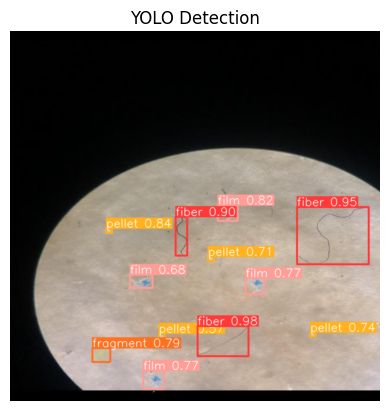

In [41]:
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# Load trained model (IMPORTANT: use best.pt)
model = YOLO("runs/detect/train/weights/best.pt")

# Run inference
results = model("test.jpg")

# Visualize
vis_img = results[0].plot()

plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.title("YOLO Detection")
plt.axis("off")
plt.show()

In [42]:
def risk_score(label, size):
    # Base risk by type
    if label == "fiber":
        score = 80
    elif label == "fragment":
        score = 60
    elif label == "film":
        score = 50
    else:  # pellet
        score = 40

    # Size effect (smaller = more dangerous)
    if size < 50:
        score += 15
    elif size < 100:
        score += 10
    else:
        score += 5

    return min(score, 100)

In [43]:
class_names = ['fiber', 'film', 'fragment', 'pellet']

def analyze_with_risk(image_path):
    results = model(image_path)
    boxes = results[0].boxes

    final_results = []

    for box in boxes:
        cls_id = int(box.cls[0])
        label = class_names[cls_id]

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        size = max(x2 - x1, y2 - y1)

        score = risk_score(label, size)

        final_results.append({
            "label": label,
            "size": size,
            "risk": score,
            "bbox": (x1, y1, x2, y2)
        })

    return final_results, results[0].plot()

In [44]:
results, vis_img = analyze_with_risk("test.jpg")

for r in results:
    print(r)


image 1/1 c:\Users\HP\OneDrive\Desktop\synapse\test.jpg: 640x640 3 fibers, 4 films, 1 fragment, 4 pellets, 197.9ms
Speed: 4.5ms preprocess, 197.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
{'label': 'fiber', 'size': 88, 'risk': 90, 'bbox': (324, 510, 412, 562)}
{'label': 'fiber', 'size': 124, 'risk': 85, 'bbox': (496, 304, 620, 403)}
{'label': 'fiber', 'size': 67, 'risk': 90, 'bbox': (286, 321, 306, 388)}
{'label': 'pellet', 'size': 10, 'risk': 55, 'bbox': (166, 341, 176, 349)}
{'label': 'film', 'size': 34, 'risk': 65, 'bbox': (359, 301, 393, 328)}
{'label': 'fragment', 'size': 31, 'risk': 75, 'bbox': (142, 548, 173, 572)}
{'label': 'film', 'size': 36, 'risk': 65, 'bbox': (230, 587, 266, 619)}
{'label': 'film', 'size': 32, 'risk': 65, 'bbox': (407, 427, 439, 455)}
{'label': 'pellet', 'size': 9, 'risk': 55, 'bbox': (519, 521, 528, 528)}
{'label': 'pellet', 'size': 10, 'risk': 55, 'bbox': (342, 390, 352, 398)}
{'label': 'film', 'size': 39, 'risk': 65, 'bbox': (20